<a href="https://colab.research.google.com/github/minakshmi12/multiagent/blob/main/Content_Writer_Multi_Agents_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multi-Agent Content Writer — LangGraph Assignment**

## **Problem Statement**

Build a **multi-agent system** using LangGraph that acts as a smart content assistant. The system should have a **router** that reads the user's request and sends it to the right agent:

- **SEO Blog Writer** — writes long-form blog posts, uses research & keyword tools autonomously
- **X/Twitter Writer** — writes short tweets (<280 chars), uses trending topic tools autonomously
- **General Handler** — answers everything else (greetings, questions, etc.) using conversation memory

The system must support **tool-calling loops** (agent calls a tool → gets result → decides to call another tool or finish) and **persistence** (remembers past conversations using a checkpointer so follow-up questions like "what was my last request?" work).

### Architecture

```
                 ┌→ SEO Blog Writer ↔ tools (loop)
User → Router ───┼→ X/Twitter Writer ↔ tools (loop)
                 └→ General Handler → END
```

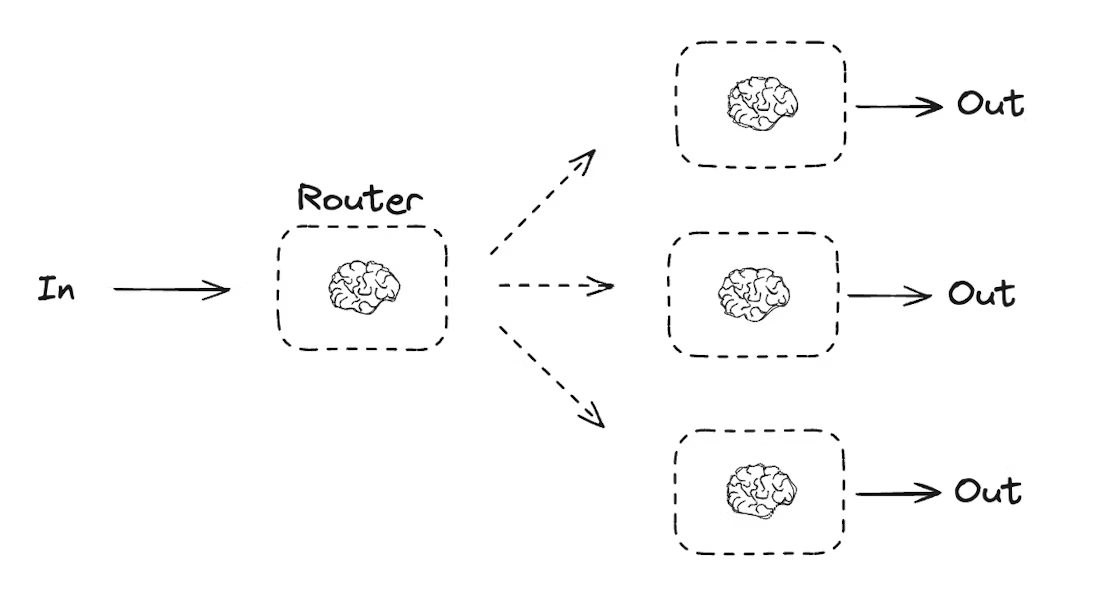




## **💡Tips**

You don't have to use mock data — you can make your tools actually work!

`research_tool` → Use a Deep Research agent (Tavily Deep Search, Perplexity API) to fetch real articles, papers, and references. These calls are heavier and costlier, so design your agent to call this once or twice for in-depth content gathering — not repeatedly.

---


`internet_search_tool` → Use SerpAPI, Google Custom Search API, or Tavily basic search for quick lookups like SEO keywords, trending topics, and hashtags. These are lighter and cheaper, so it's okay if the agent calls this multiple times.


---


**Think about cost-efficiency:** In your agent's system prompt, guide it on when to use which tool — e.g., "Use research_tool first to gather deep content, then use internet_search_tool for SEO keywords and trends. Avoid calling research_tool always." This is how real-world agents are designed — you control tool usage through smart prompting, not just by giving access.


## **Steps**




### Step 1: Setup
Install `langgraph`, `langchain`, `langchain-openai`. Configure your LLM.


In [ ]:
!pip install -U -q langgraph langchain # Write your code here

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.8/161.8 kB 4.1 MB/s eta 0:00:00


In [ ]:
!pip install -q langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 22.1 MB/s eta 0:00:00


In [ ]:
import getpass
import os
from google.colab import userdata
#os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")
try:
    api_key_from_secrets = userdata.get("OPENAI_API_KEY")
    os.environ["OPENAI_API_KEY"] = api_key_from_secrets
except Exception:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")


In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini",temperature=0.2,)

In [ ]:
test_msg = llm.invoke("What is Machine Learning? Explain with the help of an example.") #stream or invoke

In [ ]:
print(test_msg.content)

Machine Learning (ML) is a subset of artificial intelligence (AI) that focuses on the development of algorithms and statistical models that enable computers to perform specific tasks without explicit instructions. Instead of being programmed to perform a task, machine learning systems learn from data, identifying patterns and making decisions based on that data.

### Key Concepts of Machine Learning:
1. **Data**: The foundation of machine learning. It can be structured (like tables) or unstructured (like images or text).
2. **Model**: A mathematical representation of a process that is trained on data.
3. **Training**: The process of feeding data into a model to help it learn.
4. **Prediction**: Once trained, the model can make predictions or decisions based on new, unseen data.
5. **Feedback**: The model can improve over time by learning from its mistakes.

### Example: Email Spam Detection

**Problem**: Identifying whether an email is spam or not.

1. **Data Collection**: Gather a lar

### Step 2: Define State
Create a shared `TypedDict` with: `user_input`, `route`, `output`, `messages`. Use `add_messages` reducer on messages.



In [ ]:
from typing import TypedDict, Annotated, List, Optional
import operator
from langchain.messages import AnyMessage
from pydantic import BaseModel, Field
from typing import Literal

In [ ]:
class AgentTask(BaseModel):
    """A single agent task with targeted query."""
    source: Literal["seo_blog_writer", "x_blog_writer","general"] # Where to send it to
    user_query: str # Original user query
    focus: str = ""  # What aspect this agent should focus on: Write long -form  blog posts(research and keyword tools) OR write short tweets (trending topic tools), answer anything else using conversation memory c

In [ ]:
#### MAIN GRAPH STATE ######

class ContentWriterPlannerState(TypedDict):
    """Enhanced state for parallel execution."""

    # Conversation history => message_history
    messages: Annotated[List[AnyMessage], operator.add] #reducer

    # Current user query
    user_query: str

    # Tasks from router (replaces single classification)
    tasks: List[AgentTask]

    # Flag for synthesis#
    requires_synthesis: bool

    # Parallel agent results - KEY: uses operator.add for concurrent writes
    agent_results: Annotated[List[dict], operator.add]

    # Final synthesized answer
    final_answer: str

    search_messages: Annotated[List[AnyMessage], operator.add]
    planner_messages: Annotated[List[AnyMessage], operator.add]


### Step 3: Router Node
Classifies input into `seo_blog_writer` / `x_blog_writer` / `general`. Returns only one word. Also persists user input into messages.



In [ ]:
from langgraph.types import Send
from langchain.messages import SystemMessage, ToolMessage, HumanMessage, AIMessage

In [ ]:
# STRUCTURED OUTPUT SCHEMA FOR ORCHESTRATOR

class ClassificationResult(BaseModel):
    """Router output - now supports MULTIPLE parallel tasks."""
    tasks: List[AgentTask] = Field(
        description="List of agents to invoke with their targeted queries"
    )
    requires_synthesis: bool = Field(
        default=False,
        description="Whether multiple agents are being used and synthesis is needed"
    )

In [170]:
def classify_query_parallel(state: ContentWriterPlannerState) -> dict: #node
    """
    Updated router that can dispatch to MULTIPLE agents.
    """
    print("--- Inside classify_query_parallel ---")
    print(f"State messages received by classify_query_parallel: {state.get('messages', [])}")

    router_llm = llm
    structured_llm = router_llm.with_structured_output(ClassificationResult)
    result = structured_llm.invoke([
        {"role": "system",
            "content": """ You are a Content creater Router that can dispatch to MULTIPLE agents in parallel.

AVAILABLE AGENTS:
1. seo_blog_writer - writes long-form blog posts,uses research & keyword tools autonomously
2. x_blog_writer - writes short tweets (<280 chars), uses trending topic tools autonomously
3. general - write any general queries like: greetings, questions, chit-chat, request about the conversation itself (e.g. "what did I ask before?")

ROUTING RULES:

SINGLE AGENT (requires_synthesis = false):
- Research/keyword tools ONLY → seo_blog_writer
- trending topic tools ONLY → x_blog_writer
- General (greetings, questions etc)→ use conversational memory of llm

MULTIPLE AGENTS (requires_synthesis = true):
- “Write long-form posts AND short tweets AND general ” → ALL agents
- "Write long-form posts AND short tweets" → seo_blog_writer and x_blog_writer
- “Write long-form posts AND general” → seo_blog_writer agent and general
-“short tweets AND general” -> x_blog_writer and general

When dispatching to agents:
1. Create a focused sub-query for each agent
2. seo_blog_writer node query should focus on research /keyword tools
3. x_blog_writer node query should focus on tweets
4. genaral node query should focus on answer from llm with conversation memory

EXAMPLES:

Query: "Write a blog post about remote work productivity tips"
→ tasks: [{"source": "seo_blog_writer", "user_query": "Write a blog post about remote work productivity tip"}]
→ requires_synthesis: false

Query: "Write a tweet about the new iPhone launch"
→ tasks: [{"source": "x_blog_writer", "user_query": "Write a tweet about the new iPhone launch"}]
→ requires_synthesis: false

Query: "Write a blog post about remote work productivity  and tweets something about whty most productivity apps fail ”
→ tasks: [
    {"source": "seo_blog_writer", "user_query": "Write a blog post about remote work productivity ", "focus": "blog"},
    {"source": "x_blog_write", "user_query": "tweets something about why most productivity apps fail, ", "focus": "tweets"}
  ]
→ requires_synthesis: true

Query: "Hey, how are you?"
→ tasks: [
    {"source": "general", "user_query": "Hey, how are you?", "focus": "general"},
  ]
→ requires_synthesis: false """},
        {"role": "user", "content": state["user_query"]}])

    # Add the current user query as a HumanMessage to the state's messages
    # This will be appended to the overall messages list by the reducer (operator.add)
    # It ensures the current query is part of the history for subsequent steps/nodes.
    # The checkpointer will then save this complete history.
    messages_to_return = [HumanMessage(content=state["user_query"])]
    print(f"Messages that classify_query_parallel will return: {messages_to_return}")
    return {
        "tasks": result.tasks,
        "requires_synthesis": result.requires_synthesis,
        "messages": messages_to_return
    }

In [171]:
from langgraph.types import Send

# Dispatch at most one worker per agent source. Multiple search tasks
# (for example, flights + hotels) are combined into one isolated worker.
def dispatch_to_agents(state: ContentWriterPlannerState):
    print("--- Inside dispatch_to_agents ---")
    print(f"State messages received by dispatch_to_agents: {state.get('messages', [])}")

    grouped_tasks = {}

    for task in state.get("tasks", []):
        grouped_tasks.setdefault(task.source, []).append(task)

    sends = []

    for source, tasks_for_source in grouped_tasks.items():
        combined_query = (
            (chr(10) * 2).join(f"- {task.user_query}" for task in tasks_for_source)
        )

        worker_state = {
            "messages": state.get("messages", []),
            "user_query": combined_query,
            "tasks": tasks_for_source,
            "requires_synthesis": state.get("requires_synthesis", False),
            "agent_results": [],
            "final_answer": "",
            "search_messages": (
                [HumanMessage(content=combined_query)]
                if source == "search_agent_node"
                else []
            ),
            "planner_messages": (
                [HumanMessage(content=combined_query)]
                if source == "planner_agent_node"
                else []
            ),
        }

        sends.append(Send(source, worker_state))

    return sends

In [ ]:
###SYNTHESIZER###

def synthesizer_node(state: ContentWriterPlannerState) -> dict:
    """
    Combines results from parallel agents into a unified response.
    Only called when requires_synthesis is True.
    """

    agent_results = state.get("agent_results", [])


    if not agent_results:
        return {
            "final_answer": "I couldn't process your request.",
            "messages": [AIMessage(content="I couldn't process your request.")]
        }


    # If only one result, no synthesis needed
    if len(agent_results) == 1:
        result = agent_results[0]["result"]
        return {
            "final_answer": result,
            "messages": [AIMessage(content=result)] #operator.add
        }

    # Format results for synthesis
    # **RESEARCH_BLOG_AGENT**
    #  Focus: research
    #  (fblogs here)

    #  ==================================================

    #  **TWEET_AGENT**
    #  Focus: tweets
    #  (tweet here)
    results_formatted = "\n\n" + "="*50 + "\n\n".join([
        f"**{r['agent'].upper()}**\nFocus: {r.get('focus', 'N/A')}\n\n{r['result']}"
        for r in agent_results
    ])

    synthesis_prompt = """You are a Travel Response Synthesizer. Combine multiple agent outputs into
a single, well-organized, comprehensive response.

RULES:
1. Organize logically (e.g., Research → Tweet → general)
2. Don't repeat information
3. Highlight key recommendations
4. Note any conflicts or alternatives
5. Create clear sections with headers
6. End with actionable next steps

Original Query: {query}

Agent Results:
{results}

Create a unified, helpful response:"""

    response = llm.invoke([
        HumanMessage(content=synthesis_prompt.format(
            query=state["user_query"],
            results=results_formatted
        ))
    ])

    return {
        "final_answer": response.content,
        "messages": [AIMessage(content=response.content)]
    }


### Step 4: Tools
Define 2 tools with `@tool`: `research_tool` (finds articles/references) and `internet_search_tool` (finds SEO keywords/trending topics). Mock responses are fine.



research_tool → Use a Deep Research agent (Tavily Deep Search, Perplexity API) to fetch real articles, papers, and references. These calls are heavier and costlier, so design your agent to call this once or twice for in-depth content gathering — not repeatedly.


In [ ]:
# research_tool → Use a Deep Research agent (Tavily Deep Search, Perplexity API) to fetch real articles, papers, and references. These calls are heavier and costlier, so design your agent to call this once or twice for in-depth content gathering — not repeatedly.
import getpass
import os
from google.colab import userdata

# Install the tavily library
!pip install tavily

# Necessary Imports

from typing import Literal
from tavily import TavilyClient


  Preparing metadata (setup.py) ... done
  Created wheel for tavily: filename=tavily-1.1.0-py3-none-any.whl size=6186 sha256=dbea93381cd10b5ef6da46922fe6788b1f909f4c50bb66209ad684f4c1d9160f
  Stored in directory: /root/.cache/pip/wheels/df/60/d8/883106a49d84c6a06cf0690728f44bca27a214ce10c628e28d
Successfully built tavily


In [ ]:
!pip install deepagents
from langchain.chat_models import init_chat_model #Not ChatOpenAI
from deepagents import create_deep_agent

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.9/326.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 768.5/768.5 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 8.8 MB/s eta 0:00:00
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.12.1
    Uninstalling langsmith-0.12.1:
      Successfully uninstalled langsmith-0.12.1
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.49.0
    Uninstalling google-auth-2.49.0:

In [ ]:
# Re-install deepagents to ensure it's correctly recognized
!pip install -q deepagents

In [ ]:
from langchain.chat_models import init_chat_model
from deepagents import create_deep_agent

In [ ]:
import getpass
import os
from google.colab import userdata

# Import API Keys

try:
    api_key_from_secrets = userdata.get("TAVILY_API_KEY")
    os.environ["TAVILY_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")

In [ ]:
# Create Blog Search vis TavilySearch #TOOL
!pip install -q langchain-tavily
from langchain_tavily import TavilySearch #Already a tool no need for @tool

internet_search = TavilySearch( #internet_search is a tool @tool
    max_results=5,
    topic="general",
    include_images=True,
    include_image_descriptions=True,
    search_depth="advanced",
)

In [ ]:
# Test Blog_search tavily
internet_search.invoke({"query": "Write a blog post about remote work productivity tips"})

{'query': 'Write a blog post about remote work productivity tips',
 'follow_up_questions': None,
 'answer': None,
 'images': [{'url': 'https://demmelearning.com/wp-content/uploads/2020/11/Can-You-Save-By-Working-From-Home-Infographic-410x1024.jpg',
   'title': '10 Tips for Working Remotely [Infographic]',
   'description': 'The infographic outlines the benefits of remote work for both employees, highlighting savings on gas, food, clothing, and increased free time, and for employers, emphasizing reduced turnover, absenteeism, and enhanced productivity.'},
  {'url': 'https://cdn.thomasgriffin.com/wp-content/uploads/2024/04/tips-for-working-remotely-successfully-1-477x920.png',
   'title': '21 Remote Work Tips for Maximum Productivity in 2024 - Thomas Griffin',
   'description': 'A list of 21 tips for working remotely successfully is presented alongside colorful icons, including a stopwatch, a computer, a group of people, and a megaphone, emphasizing organization, technology, communicatio

Deep Research Agent

In [ ]:
import getpass
import os
from google.colab import userdata
from langchain.chat_models import init_chat_model # Ensure this is imported if not globally available

# Ensure OpenAI API key is set before initializing the model
try:
    api_key_from_secrets = userdata.get("OPENAI_API_KEY")
    os.environ["OPENAI_API_KEY"] = api_key_from_secrets
except Exception:
    if "OPENAI_API_KEY" not in os.environ:
        os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

# Define Model for Deep Research Agent - nLATER I WANT TO WRAP THIS IN @TOOL so I CAN USE IT AS A SUBAGENT/TOOL
model = init_chat_model(model="gpt-4o-mini",
                        model_provider="openai",
                        temperature=0.2)

In [ ]:
# Itinerary Agent (Deep Research) Prompt

from deepagents import create_deep_agent

research_instructions = """You are an expert SEO blog writer specializing  in find long blogs and posting relevant to given query.

SCOPE AND BEHAVIOR RULES
- Respond ONLY to long blog-related requests, including posts, article, draft, paper etc .
- If a request is unrelated to long blogs(e.g.,  general query “greeting”, “permission” etc), politely decline and redirect the user to a internet-search request.
- Do NOT answer hypothetical or fictional questions unless explicitly stated by the user.

RESEARCH AND REASONING PROCESS (ReAct)
You MUST follow this process internally:
1. THOUGHT: Analyze the user’s blog goals, constraints, preferences, and missing information.
2. ACTION: Use TavilySearch to retrieve current, authoritative  data (blogs,articles,posts,citations etc).
3. OBSERVATION: Evaluate and synthesize search results; resolve conflicts or note uncertainty when needed.
4. RESPONSE: Produce a complete, user-ready itinerary.

TOOL USAGE
- TavilySearch is the primary tool for researching up-to-date blog information.
- Prefer official blogs,posts for content writing.
- Do not fabricate details if information is unavailable; explicitly state assumptions or gaps.

OUTPUT REQUIREMENTS
All itineraries MUST include:
- A clear paragraph structure  with proper heading, module names
- Make sure indentation are proper
- Word format should same throughout the blog or post


FORMATTING GUIDELINES
- Use clear headings and bullet points
- Optimize for readability and execution during reading
- Be concise but thorough; avoid filler or generic advice

QUALITY BAR
- Prioritize realism, efficiency, and blogger experience
- Tailor recommendations to blogger type when information is available
- If critical details are missing, ask targeted clarification questions before finalizing the response

"""


In [ ]:
# Blogger Research Agent (deep research agent)
blogger_research_agent = create_deep_agent(
    model=model,
    system_prompt=research_instructions,
    tools=[internet_search], #TAVILY
)

In [ ]:
# Test Deep Research Ageent (Blogger Research Agent)
result = blogger_research_agent.invoke({"messages": [{"role": "user",
                                                        "content": "Draft a how-to guide for setting up a home coffee bar"}]})

print(result)

{'messages': [HumanMessage(content='Draft a how-to guide for setting up a home coffee bar', additional_kwargs={}, response_metadata={}, id='57c74b8c-6430-4d1a-9ba2-6af6893cbfe7'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 3527, 'total_tokens': 3551, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_fe981518f3', 'id': 'chatcmpl-EOoDqYr8DrLRXyONrrM9j3DLEiHV0', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0ab60-a7d6-7522-9253-3a966a4bf6d7-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'how to set up a home coffee bar guide'}, 'id': 'call_hsCnJtcgnLQ66xLlN26H36Yh', 

In [ ]:
# Print the agent's response
print(result["messages"][-1].content)

# How to Set Up a Home Coffee Bar: A Comprehensive Guide

Creating a home coffee bar is an exciting way to enhance your coffee experience, allowing you to brew café-quality beverages in the comfort of your own home. This guide will walk you through the essential steps to set up a functional and stylish coffee bar that suits your personal taste and lifestyle.

## 1. Choose the Right Location

### Ideal Spot
- **Accessibility**: Select a location near a power outlet and, if possible, a water source. This will make brewing coffee more convenient.
- **Lighting**: Avoid direct sunlight to preserve the quality of your coffee beans and syrups.
- **Space**: Ensure you have enough space for your equipment and accessories without feeling cramped.

## 2. Gather Essential Equipment

### Core Equipment
- **Coffee Maker**: Choose between an espresso machine, drip coffee maker, French press, or pour-over setup based on your preference.
- **Grinder**: Invest in a quality burr grinder for consistent co

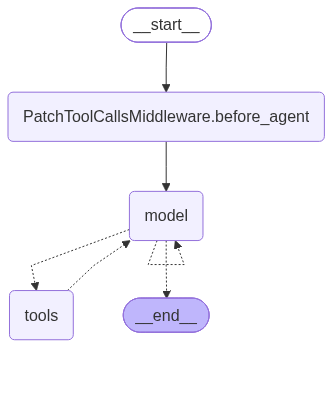

In [ ]:
from IPython.display import Image, display

display(Image(blogger_research_agent.get_graph().draw_mermaid_png()))

blogger_research_agent as a TOOL (Sub Agent)


In [ ]:
# Defining blogger_research_agent as a Tool / DEEP RESEARCH AGENT AS A TOOL
from langchain.tools import tool

@tool("blogger_research_agent", description="search for blogs with long content")
def call_blogger_research_agent(query: str):
    result = blogger_research_agent.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content

In [ ]:
research_tools=[internet_search, call_blogger_research_agent]

tools using serp API for finding SEO key words and trending topics

In [ ]:
import getpass
import os
from google.colab import userdata



In [ ]:
    # API Key SetUp (Using Serp API for find SEO key words and trending topics)
    try:
        api_key_from_secrets = userdata.get("SERPAPI_API_KEY")
        os.environ["SERPAPI_API_KEY"] = api_key_from_secrets
    except Exception:
            os.environ["SERPAPI_API_KEY"] = getpass.getpass("Enter your Serp API key: ")

In [ ]:
# Install required libraries

!pip install -q google-search-results

  Preparing metadata (setup.py) ... done


In [ ]:
!pip install -q langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.0 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
from langchain_community.utilities import SerpAPIWrapper
from serpapi import GoogleSearch

/tmp/ipykernel_2931/1097158722.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SerpAPIWrapper


In [ ]:
import os
import json
from typing import Optional
from pydantic import BaseModel, Field #validation
from serpapi import GoogleSearch
from langchain_core.tools import tool

In [172]:

# ---------------------------------------------------------------------------
# 5. GOOGLE SERP INSIGHTS - related searches, People Also Ask, ad density
#    (useful proxy for keyword difficulty / intent when you don't have a
#     dedicated keyword-volume API)
# ---------------------------------------------------------------------------

class SerpKeywordInsightsInput(BaseModel):
    """Input schema for pulling keyword insights from a live Google SERP."""

    query: str = Field(..., description="Keyword/topic to analyze, e.g. 'how to start a podcast'")
    country: Optional[str] = Field(None, description="Country code, e.g. 'us'")
    language: Optional[str] = Field(None, description="Language code, e.g. 'en'")
    location: Optional[str] = Field(None, description="Specific location, e.g. 'Austin, Texas, United States'")


@tool(args_schema=SerpKeywordInsightsInput)
def search_keyword_serp_insights(
    query: str,
    country: Optional[str] = None,
    language: Optional[str] = None,
    location: Optional[str] = None,
) -> str:
    """Analyze a live Google SERP for a keyword: related searches, People Also Ask questions,
    number of ads (commercial intent signal), and total indexed results (competition signal)."""

    params = {
        "api_key": os.environ.get("SERPAPI_API_KEY"),
        "engine": "google",
        "q": query,
    }
    if country:
        params["gl"] = country.lower()
    if language:
        params["hl"] = language.lower()
    if location:
        params["location"] = location

    try:
        results = GoogleSearch(params).get_dict()

        related_searches = [r.get("query") for r in results.get("related_searches", [])]
        people_also_ask = [
            q.get("question") for q in results.get("related_questions", [])
        ]
        ads_count = len(results.get("ads", []))
        total_results = results.get("search_information", {}).get("total_results")
        organic_top10 = [
            {"position": r.get("position"), "title": r.get("title"), "link": r.get("link")}
            for r in results.get("organic_results", [])[:10]
        ]

        output = {
            "query": query,
            "total_indexed_results": total_results,
            "ads_on_page": ads_count,
            "related_searches": related_searches,
            "people_also_ask": people_also_ask,
            "top_organic_results": organic_top10,
        }
        return json.dumps(output, indent=2)

    except Exception as e:
        return json.dumps({"error": str(e)})


In [173]:

# ---------------------------------------------------------------------------
# 3. GOOGLE TRENDS - TRENDING NOW (realtime trending searches by country)
# ---------------------------------------------------------------------------

class TrendingNowInput(BaseModel):
    """Input schema for realtime trending searches."""

    geo: str = Field("US", description="Country code for trending searches, e.g. 'US', 'GB', 'IN'")
    category: Optional[str] = Field(
        None,
        description="Optional category id to filter trends (e.g. 'e' for entertainment, 'b' for business)",
    )
    only_active: bool = Field(True, description="If true, only return currently active trends")


@tool(args_schema=TrendingNowInput)
def search_trending_now(
    geo: str = "US",
    category: Optional[str] = None,
    only_active: bool = True,
) -> str:
    """Get realtime trending topics/searches for a given country right now."""

    params = {
        "api_key": os.environ.get("SERPAPI_API_KEY"),
        "engine": "google_trends_trending_now",
        "geo": geo.upper(),
        "only_active": "true" if only_active else "false",
    }
    if category:
        params["trend_category"] = category

    try:
        results = GoogleSearch(params).get_dict()
        trends = results.get("trending_searches", [])

        if not trends:
            return json.dumps({"message": "No trending searches found"})

        output = []
        for t in trends[:25]:
            output.append({
                "query": t.get("query"),
                "search_volume": t.get("search_volume"),
                "increase_percentage": t.get("increase_percentage"),
                "categories": [c.get("name") for c in t.get("categories", [])],
                "trend_breakdown": t.get("trend_breakdown"),
                "started_timestamp": t.get("start_timestamp"),
            })
        return json.dumps(output, indent=2)

    except Exception as e:
        return json.dumps({"error": str(e)})



# ---------------------------------------------------------------------------
# Registering the tools for a LangChain agent
# ---

In [ ]:
internet_search_tool=[search_keyword_serp_insights,search_trending_now]

# API Key SetUp (Using Serp API for keyword and trending topic)

try:
    api_key_from_secrets = userdata.get("SERPAPI_API_KEY")
    os.environ["SERPAPI_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["SERPAPI_API_KEY"] = getpass.getpass("Enter your Serp API key: "

internet_search_tool → Use SerpAPI, Google Custom Search API, or Tavily basic search for quick lookups like SEO keywords, trending topics, and hashtags. These are lighter and cheaper, so it's okay if the agent calls this multiple times.


### Step 5: SEO Blog Writer
Bind both tools to LLM. Agent checks state messages for tool loop continuation. Writes structured blog with headings and CTA.



In [ ]:
SEO_SYSTEM_PROMPT = """You are an expert SEO blog writer.
For every request:
1. Use `keyword_research` to find a primary keyword and supporting long-tail keywords.
2. Use `search_web` to gather facts/angles to make the post credible and current.
3. Only after you have both, write a complete, well-structured, long-form blog
   post (headline, intro, H2 sections, conclusion) that naturally includes the
   researched keywords.
Do not skip the tools even if you think you already know the topic well.
"""

In [ ]:
mode=llm

In [ ]:
#Research Agent
from langchain.agents import create_agent

research_agent = create_agent(
    model=model,  # Default model
    tools=research_tools,
    system_prompt=SEO_SYSTEM_PROMPT
    # middleware=[dynamic_model_selection]
)

In [ ]:
query="need a long-form article on the benefits of intermittent fasting"
for event in research_agent.stream(
    {"messages": [{"role": "user",
                   "content": query}]},
    stream_mode="values",
):
    print(event["messages"][-1])

content='need a long-form article on the benefits of intermittent fasting' additional_kwargs={} response_metadata={} id='1382e70e-360a-4490-a38c-5d6de4e3ef8e'
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 1330, 'total_tokens': 1392, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c577bb8647', 'id': 'chatcmpl-EOoGMiN5T0Pf5ywGCYEGQRLlmeNCV', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--01a0ab63-0815-7003-ae2b-c45ae1c3d368-0' tool_calls=[{'name': 'tavily_search', 'args': {'query': 'benefits of intermittent fasting', 'search_depth': 'advanced'}, 'id': 'call_4nShWo8LXS47R2MaBlfuX7r8', 'type': 'too

### Step 6: X/Twitter Writer
Bind only `internet_search_tool`. Same loop pattern. Writes short posts with emojis and hashtags.



In [ ]:
TWITTER_SYSTEM_PROMPT = """You are a sharp, punchy X/Twitter ghostwriter.
For every request:
1. Use `get_trending_topics` to check what's currently trending in the
   relevant niche, so the tweet can ride a real trend or hot take angle.
2. Then write the final tweet. HARD CONSTRAINT: it must be under 280
   characters, no exceptions. Prefer punchy, concrete, opinionated copy over
   generic statements. Include at most 1-2 hashtags.
Do not skip the tool even if you think you already know what's trending.
"""

In [ ]:
from langchain.agents import create_agent
twitter_agent = create_agent(
    model=model,  # Default model
    tools=internet_search_tool,
    system_prompt=TWITTER_SYSTEM_PROMPT
    # middleware=[dynamic_model_selection]
)

In [ ]:
query="Write a tweet about the new iPhone launch"
search_results=twitter_agent.invoke({"messages": [{"role": "user",
                                                   "content": query}]})
print(search_results)

{'messages': [HumanMessage(content='Write a tweet about the new iPhone launch', additional_kwargs={}, response_metadata={}, id='9d7f04d1-e7b3-41cc-881d-0318a668f174'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 389, 'total_tokens': 405, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a43c9a2adc', 'id': 'chatcmpl-EOoHp3uTI5ljsW27JsN08GEZvYsy6', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0ab64-6f69-7de0-b680-53fab18c7461-0', tool_calls=[{'name': 'search_trending_now', 'args': {'geo': 'US'}, 'id': 'call_5vnD6z1Wnjc9b10apq9O47ql', 'type': 'tool_call'}], invalid_tool_calls=[],

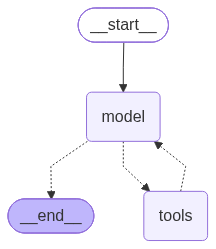

In [ ]:
from IPython.display import Image, display

display(Image(twitter_agent.get_graph().draw_mermaid_png()))

### Step 7: General Handler
Uses full message history from state to answer general queries with context. Saves both user and AI messages for persistence.




# ---------------------------------------------------------------------------
# 7. General Handler agent (no tools, just memory-aware conversation)
# -----------------------------------------------------------------------

In [130]:
GENERAL_SYSTEM_PROMPT = """You are a friendly, helpful assistant for a content
creation tool. Answer greetings, general questions, and meta-questions about
the conversation (e.g. "what did I last ask you?, Hello,How are you? etc") using the full chat
history available to you. Keep answers concise and conversational."""

In [165]:
def general_handler_node(state:ContentWriterPlannerState ) -> dict:
    print("--- Inside general_handler_node ---")
    print(f"State messages: {state['messages']}")
    messages = [SystemMessage(content=GENERAL_SYSTEM_PROMPT)] + state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response], "final_answer": response.content}

In [132]:
research_model_with_tools = llm.bind_tools(research_tools)

In [133]:
internet_search_model_with_tools=llm.bind_tools(internet_search_tool)

In [134]:
def seo_blog_writer(state:ContentWriterPlannerState):
    """Search agent with its own message history"""

    # Use search-specific messages
    search_msgs = state.get("search_messages", []) #history messages = empty
    messages = [SystemMessage(content=SEO_SYSTEM_PROMPT)] + search_msgs

    # If this is first call, add the user query
    if not search_msgs:
        messages.append(HumanMessage(content=state.get("user_query", "")))

    response = research_model_with_tools.invoke(messages)
    # response.tool_calls

    return {
        "search_messages": [response], #use that reducer operator.add
        "agent_results": [{
            "agent": "research_agent",
            "focus": "blogs and article",
            "result": response.content # llm responding
        }] if not response.tool_calls else [] #a message carrying tool_calls is not an answer — its .content is usually empty.
        # You only publish to agent_results when the agent actually stopped calling tools.
    }

In [135]:
def seo_blog_writer_tool_node(state: ContentWriterPlannerState):
    """Execute search tools"""
    search_msgs = state.get("search_messages", [])

    if not search_msgs:
        return {"search_messages": []}

    last_message = search_msgs[-1]

    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return {"search_messages": []}

    result = []
    research_tools_by_name={tool.name: tool for tool in research_tools}
    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool = research_tools_by_name.get(tool_name)
        if tool:
            try:
                observation = tool.invoke(tool_call["args"])
                result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
            except Exception as e:
                # Catch exceptions during tool invocation and still return a ToolMessage
                error_content = json.dumps({"error": f"Tool {tool_name} failed with: {str(e)}"})
                result.append(ToolMessage(content=error_content, tool_call_id=tool_call["id"]))
                print(f"ERROR: Tool {tool_name} invocation failed for ID {tool_call['id']}: {e}")
        else:
            # If tool not found, still return a ToolMessage to satisfy the API
            missing_tool_error = f"ERROR: Tool '{tool_name}' not found in search_tools_by_name for tool_call_id: {tool_call['id']}"
            result.append(ToolMessage(content=json.dumps({"error": missing_tool_error}), tool_call_id=tool_call["id"]))
            print(missing_tool_error)

    return {"search_messages": result}

In [136]:
def x_blog_writer(state:ContentWriterPlannerState):
    """Search agent with its own message history"""

    # Use search-specific messages
    search_msgs = state.get("xblog_messages", []) #history messages = empty
    messages = [SystemMessage(content=SEO_SYSTEM_PROMPT)] + search_msgs

    # If this is first call, add the user query
    if not search_msgs:
        messages.append(HumanMessage(content=state.get("user_query", "")))

    response = internet_search_model_with_tools.invoke(messages)
    # response.tool_calls

    return {
        "xblog_messages": [response], #use that reducer operator.add
        "agent_results": [{
            "agent": "twitter_agent",
            "focus": "trending topics",
            "result": response.content # llm responding
        }] if not response.tool_calls else [] #a message carrying tool_calls is not an answer — its .content is usually empty.
        # You only publish to agent_results when the agent actually stopped calling tools.
    }

In [137]:
def xblog_writer_tool_node(state: ContentWriterPlannerState):
    """Execute search tools"""
    search_msgs = state.get("xblog_messages", [])

    if not search_msgs:
        return {"xblog_messages": []}

    last_message = search_msgs[-1]

    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return {"xblog_messages": []}

    result = []
    internet_tools_by_name={tool.name: tool for tool in internet_search_tool}
    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool = internet_tools_by_name.get(tool_name)
        if tool:
            try:
                observation = tool.invoke(tool_call["args"])
                result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
            except Exception as e:
                # Catch exceptions during tool invocation and still return a ToolMessage
                error_content = json.dumps({"error": f"Tool {tool_name} failed with: {str(e)}"})
                result.append(ToolMessage(content=error_content, tool_call_id=tool_call["id"]))
                print(f"ERROR: Tool {tool_name} invocation failed for ID {tool_call['id']}: {e}")
        else:
            # If tool not found, still return a ToolMessage to satisfy the API
            missing_tool_error = f"ERROR: Tool '{tool_name}' not found in search_tools_by_name for tool_call_id: {tool_call['id']}"
            result.append(ToolMessage(content=json.dumps({"error": missing_tool_error}), tool_call_id=tool_call["id"]))
            print(missing_tool_error)

    return {"xblog_messages": result}

In [138]:
def should_continue_for_researchAgent(state: ContentWriterPlannerState):
    search_msgs = state.get("search_messages", [])
    if search_msgs and hasattr(search_msgs[-1], 'tool_calls') and search_msgs[-1].tool_calls:
        return "research_tool_node"
    return "synthesizer"

In [139]:
def should_continue_for_xblogAgent(state: ContentWriterPlannerState):
    search_msgs = state.get("xblog_messages", [])
    if search_msgs and hasattr(search_msgs[-1], 'tool_calls') and search_msgs[-1].tool_calls:
        return "xblogger_tool_node"
    return "synthesizer"

In [140]:
from typing import Literal
from langgraph.graph import StateGraph, START, END

In [141]:
def build_parallel_blog_agent():
    """Build the graph with parallel execution support."""

    builder = StateGraph(ContentWriterPlannerState)

    # Add nodes
    builder.add_node("orchestrator", classify_query_parallel)
    builder.add_node("seo_blog_writer", seo_blog_writer)
    builder.add_node("x_blog_writer", x_blog_writer)
    builder.add_node("research_tool_node", seo_blog_writer_tool_node)
    builder.add_node("xblogger_tool_node", xblog_writer_tool_node)
    builder.add_node("general", general_handler_node)
    builder.add_node("synthesizer", synthesizer_node)

    # Connect edges
    builder.add_edge(START, "orchestrator")

    # Router dispatches to agents via Send API (parallel execution)
    builder.add_conditional_edges(
        "orchestrator",
        dispatch_to_agents, #dispatcher fuction
        ["seo_blog_writer", "x_blog_writer","general"]
    )

    # ReSearch agent tool loop
    builder.add_conditional_edges(
        "seo_blog_writer",
        should_continue_for_researchAgent,
        ["research_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("research_tool_node", "seo_blog_writer")

    # XBlog agent tool loop
    builder.add_conditional_edges(
        "x_blog_writer",
        should_continue_for_xblogAgent,
        ["xblogger_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("xblogger_tool_node", "x_blog_writer")

    # End after synthesis
    builder.add_edge("synthesizer", END)

    return builder.compile()

In [142]:
# Compile the agent
agent = build_parallel_blog_agent()

### Step 8: Build Graph
Add all nodes. Router → 3-way conditional edges. Agent ↔ tool loops using `should_continue` functions. General → END.



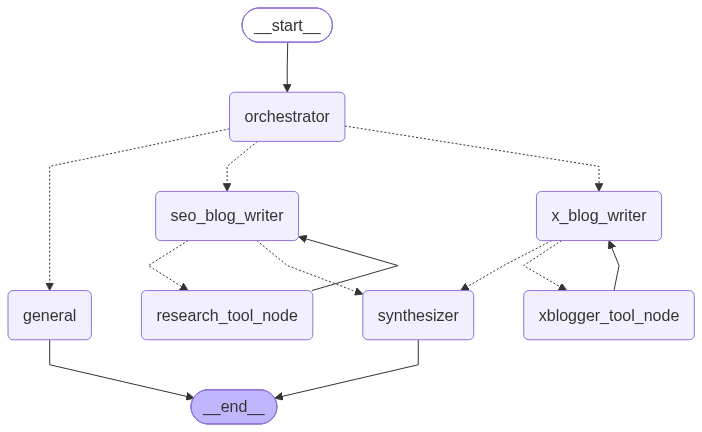

In [ ]:

from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

Test Multi Agent Content Writer

In [143]:
# Regression test: duplicate router tasks must become one worker per source
regression_state = {
    "user_query": "blogs + trending topics + general",
    "messages": [],
    "tasks": [
        AgentTask(source="seo_blog_writer", user_query="blogs", focus="blogs and article"),
        AgentTask(source="x_blog_writer", user_query="twitter writer", focus="trending topics"),
        AgentTask(source="general", user_query="general query", focus="hi,hello,greetings"),
    ],
    "requires_synthesis": True,
    "agent_results": [],
    "final_answer": "",
    "search_messages": [],
    "xblog_messages": [],
}

regression_sends = dispatch_to_agents(regression_state)
assert len(regression_sends) == 3, (
    f"Expected one worker per source (2 total), got {len(regression_sends)}"
)
print("PASS: dispatcher emits one worker per agent source")

PASS: dispatcher emits one worker per agent source


In [144]:
agent = build_parallel_blog_agent()

config = {
    "configurable": {
        "thread_id": "mina-clean-1"
    }
}

In [145]:
result = agent.invoke({
        "user_query": "Write a blog post about the future of electric bikes and then turn that into tweet and then tell what did I ask you to write about, in order?",
        "messages": []
    })

In [146]:
 #Print everything step by step
print("=" * 60)
print("USER QUERY:")
print(result["user_query"])

print("\n" + "=" * 60)
print("TASKS DISPATCHED:")
for task in result.get("tasks", []):
    print(f"  • {task.source}: {task.user_query}")

print("\n" + "=" * 60)
print("AGENT RESULTS:")
for r in result.get("agent_results", []):
    print(f"\n[{r['agent'].upper()}]")
    print("-" * 40)
    print(r["result"][:50000] + "..." if len(r["result"]) > 500 else r["result"])

print("\n" + "=" * 60)
print("FINAL SYNTHESIZED RESPONSE:")
print("=" * 60)
print(result["final_answer"])

USER QUERY:
Write a blog post about the future of electric bikes and then turn that into tweet and then tell what did I ask you to write about, in order?

TASKS DISPATCHED:
  • seo_blog_writer: Write a blog post about the future of electric bikes
  • x_blog_writer: Write a tweet about the future of electric bikes
  • general: What did I ask you to write about, in order?

AGENT RESULTS:

[RESEARCH_AGENT]
----------------------------------------
# The Future of Electric Bikes: Trends and Innovations Shaping Tomorrow's Ride

Electric bikes, or e-bikes, have rapidly transformed from niche products into mainstream transportation solutions. As we look ahead, the future of electric bikes is not just about convenience; it's about sustainability, technology, and enhanced user experience. This blog post explores the emerging trends and innovations that are set to shape the e-bike industry in the coming years.

## The Rise of E-Bikes: A Brief Overview

The e-bike market has seen exponential growt

In [153]:
result = agent.invoke(
    {
        "user_query": "Hello, how are you?"
    }
)

print(result["final_answer"])

In [154]:
print(result)

{'messages': [AIMessage(content="Hello! I'm here to help you with any questions or content creation needs you have. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 71, 'total_tokens': 95, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eae7bfcf14', 'id': 'chatcmpl-EOsiRdzRN2fMjfO2Y6alCCTWAQvI0', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0ac68-380a-7d83-86fb-6150ff0e61df-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 71, 'output_tokens': 24, 'total_tokens': 95, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 

### Step 9: Persistence
Add `MemorySaver` checkpointer. Compile graph. Pass `thread_id` in config on every call.


In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig

In [174]:
def build_parallel_blog_agent():
    """Build the graph with parallel execution support."""

    builder = StateGraph(ContentWriterPlannerState)

    # Add nodes
    builder.add_node("orchestrator", classify_query_parallel)
    builder.add_node("seo_blog_writer", seo_blog_writer)
    builder.add_node("x_blog_writer", x_blog_writer)
    builder.add_node("research_tool_node", seo_blog_writer_tool_node)
    builder.add_node("xblogger_tool_node", xblog_writer_tool_node)
    builder.add_node("general", general_handler_node)
    builder.add_node("synthesizer", synthesizer_node)

    # Connect edges
    builder.add_edge(START, "orchestrator")

    # Router dispatches to agents via Send API (parallel execution)
    builder.add_conditional_edges(
        "orchestrator",
        dispatch_to_agents, #dispatcher fuction
        ["seo_blog_writer", "x_blog_writer","general"]
    )

    # ReSearch agent tool loop
    builder.add_conditional_edges(
        "seo_blog_writer",
        should_continue_for_researchAgent,
        ["research_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("research_tool_node", "seo_blog_writer")

    # XBlog agent tool loop
    builder.add_conditional_edges(
        "x_blog_writer",
        should_continue_for_xblogAgent,
        ["xblogger_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("xblogger_tool_node", "x_blog_writer")

    # End after synthesis
    builder.add_edge("synthesizer", END)
    # Built-in Persistence
    checkpointer = InMemorySaver()


    return builder.compile(checkpointer=checkpointer)

In [ ]:
# Compile the agent
agent = build_parallel_blog_agent()

In [ ]:
config = {"configurable": {"thread_id": "mina"}}
config2 = {"configurable": {"thread_id": "arun"}}
config3 = {"configurable": {"thread_id": "prasad"}}
sree = {"configurable": {"thread_id": "sree"}}

In [ ]:
result = agent.invoke(
    {
        "user_query": "Can you write 800 words on why small businesses should use AI chatbots?",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config #mina's
)

print(result['final_answer'])

# AI Chatbots for Small Businesses: A Comprehensive Guide

In the rapidly evolving landscape of technology, AI chatbots have emerged as a vital tool for small businesses. These intelligent systems not only enhance customer engagement but also streamline operations, making them an essential asset for any small business looking to thrive in a competitive market. This blog explores the benefits, use cases, and examples of AI chatbots tailored for small businesses.

## 1. Understanding AI Chatbots

AI chatbots are software applications that simulate human conversation through text or voice interactions. They are powered by artificial intelligence, enabling them to understand and respond to customer inquiries efficiently. For small businesses, chatbots can automate tasks, answer frequently asked questions, and assist with sales or marketing efforts, significantly improving operational efficiency.

### Key Features of AI Chatbots:
- **24/7 Availability**: Unlike human staff, chatbots can ope

### Step 10: Test
- Test all 3 routes work correctly

In [148]:
result = agent.invoke(
    {
        "user_query": "Hello, how are you?",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config #mina's
)

print(result['final_answer'])

Hello! I'm here to help you with any questions or tasks you have. How can I assist you today?


In [122]:
result = agent.invoke(
    {
        "user_query": "Give me a punchy tweet promoting our SaaS product's Black Friday sale",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config #mina's
)

print(result['final_answer'])

🚀 Black Friday Alert! 🎉 Get ready to supercharge your business with our SaaS product at an unbeatable price! 💥 Enjoy exclusive discounts and elevate your productivity. Don't miss out—this deal is for a limited time only! 🔥 #BlackFriday #SaaS #Sale #ProductivityBoost


In [149]:
result = agent.invoke(
    {
        "user_query": "Draft a how-to guide for setting up a home coffee bar",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config #mina's
)

print(result['final_answer'])

# Home Coffee Bar Setup Guide

Creating a home coffee bar can transform your coffee-making experience, allowing you to enjoy café-quality beverages in the comfort of your home. This guide will walk you through the essential steps to set up your own coffee station, including equipment, organization, and design tips.

## 1. Choosing the Right Location

The first step in setting up your home coffee bar is selecting an ideal location. Consider the following:

- **Proximity to Water Source**: Ensure your coffee bar is near a sink or water source for easy access.
- **Power Outlets**: Make sure there are enough outlets for your coffee equipment.
- **Counter Space**: Aim for at least 1-2 feet of counter space to avoid clutter.

### Suggested Locations:
- Kitchen countertop
- Repurposed end table
- Rolling cart
- Dedicated cabinet space

## 2. Essential Equipment

A well-equipped coffee bar should include the following core items:

### Core Equipment:
- **Coffee Maker**: Choose between an espre

In [176]:
user_input="What was my last request?"
result = agent.invoke(


        {"user_query": user_input, "messages": []},config=config
    )
print(result['final_answer'])

Hello! I'm here to help you with any questions or content creation needs you have. How can I assist you today?


In [150]:
result = agent.invoke(
    {
        "user_query": "What was my last request?",
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config #mina's
)

print(result['final_answer'])

Hello! I'm here to help you with any questions or tasks you have. How can I assist you today?


In [151]:
result = agent.invoke(
    {
        "user_query": "What was my last query?",
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config #mina's
)

print(result['final_answer'])

Hello! I'm here to help you with any questions or content creation needs you might have. How can I assist you today?


In [152]:
result = agent.invoke(
    {
        "user_query": "Can you remind me what topic we've been talking about so far?",
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config #mina's
)

print(result['final_answer'])

Hello! I'm here to help you with any questions or content creation needs you have. How can I assist you today?


In [177]:
app=build_parallel_blog_agent()
# ---------------------------------------------------------------------------
# 10. Demo / manual test harness
# ---------------------------------------------------------------------------

def ask(user_input: str, thread_id: str = "demo-thread") -> str:
    """Send one user turn to the assistant and then the final answer."""
    config = {"configurable": {"thread_id": thread_id}}
    # The 'user_query' must be present in the initial state for the orchestrator
    # The 'messages' will be automatically added by the orchestrator via the reducer
    # The checkpointer should load the history, but it needs the 'messages' key to be present in the initial state.
    result = app.invoke({"user_query": user_input, "messages": []}, config=config)
    return result["final_answer"]


if __name__ == "__main__":
    thread = "mina"

    print("--- Turn 1: blog request (routes to seo_blog_writer, uses tools) ---")
    print(ask("Write a short blog post about morning routines for developers.", thread))

    print("\n--- Turn 2: tweet request (routes to twitter_writer, uses tools) ---")
    print(ask("Now write a tweet about the same topic.", thread))

    print("\n--- Turn 3: general/meta question (routes to general, uses memory) ---")
    #print(ask("What was my very first request in this conversation?", thread))
    #print(ask("Can you remind me what topic we've been talking about so far?", thread))
    print(ask("What was my last query?", thread))

--- Turn 1: blog request (routes to seo_blog_writer, uses tools) ---
--- Inside classify_query_parallel ---
State messages received by classify_query_parallel: []
Messages that classify_query_parallel will return: [HumanMessage(content='Write a short blog post about morning routines for developers.', additional_kwargs={}, response_metadata={})]
--- Inside dispatch_to_agents ---
State messages received by dispatch_to_agents: [HumanMessage(content='Write a short blog post about morning routines for developers.', additional_kwargs={}, response_metadata={})]
# Morning Routines for Developers: A Comprehensive Guide

Creating an effective morning routine is crucial for developers to enhance productivity, maintain focus, and set a positive tone for the day. This guide outlines various strategies and routines that developers can adopt to optimize their mornings.

## 1. The Importance of a Morning Routine

Establishing a morning routine helps in:
- **Enhancing Focus**: A structured start can mi